# 🔍 深度洞察

**目标**：分析利润与折扣的关系，挖掘亏损原因，提供业务建议

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 设置 seaborn 样式
sns.set_style('whitegrid')
sns.set_palette('husl')

print('库加载完成！')

库加载完成！


In [2]:
# 加载数据
df = pd.read_csv('../data/processed/superstore_cleaned.csv')

# 转换日期列
df['Order Date'] = pd.to_datetime(df['Order Date'])

print(f'数据加载成功！共 {len(df)} 条记录')

数据加载成功！共 9994 条记录


## 1. 利润与折扣关系分析

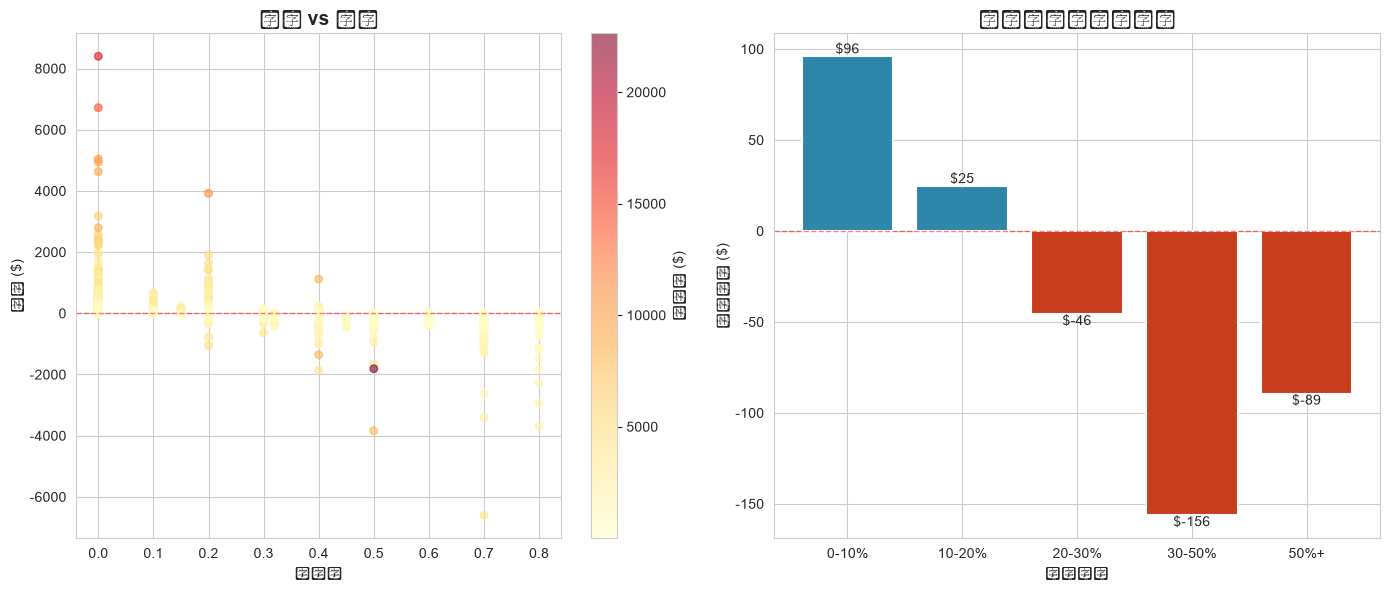

In [3]:
# 利润与折扣的散点图
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 散点图
scatter = axes[0].scatter(df['Discount'], df['Profit'], 
                          c=df['Sales'], cmap='YlOrRd', alpha=0.6, s=30)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
axes[0].set_xlabel('折扣率')
axes[0].set_ylabel('利润 ($)')
axes[0].set_title('利润 vs 折扣', fontsize=14, fontweight='bold')
plt.colorbar(scatter, ax=axes[0], label='销售额 ($)')

# 按折扣区间的平均利润
df['Discount Range'] = pd.cut(df['Discount'], 
                              bins=[0, 0.1, 0.2, 0.3, 0.5, 1.0],
                              labels=['0-10%', '10-20%', '20-30%', '30-50%', '50%+'])

discount_profit = df.groupby('Discount Range').agg({
    'Profit': 'mean',
    'Sales': 'mean'
}).reset_index()

colors = ['#2E86AB' if x > 0 else '#C73E1D' for x in discount_profit['Profit']]
bars = axes[1].bar(discount_profit['Discount Range'], discount_profit['Profit'],
                   color=colors, edgecolor='white', linewidth=1.5)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
axes[1].set_xlabel('折扣区间')
axes[1].set_ylabel('平均利润 ($)')
axes[1].set_title('各折扣区间平均利润', fontsize=14, fontweight='bold')
axes[1].bar_label(bars, fmt='$%.0f', fontsize=10)

plt.tight_layout()
plt.show()

📊 相关性矩阵
          Sales  Quantity  Discount  Profit
Sales     1.000     0.201    -0.028   0.479
Quantity  0.201     1.000     0.009   0.066
Discount -0.028     0.009     1.000  -0.219
Profit    0.479     0.066    -0.219   1.000


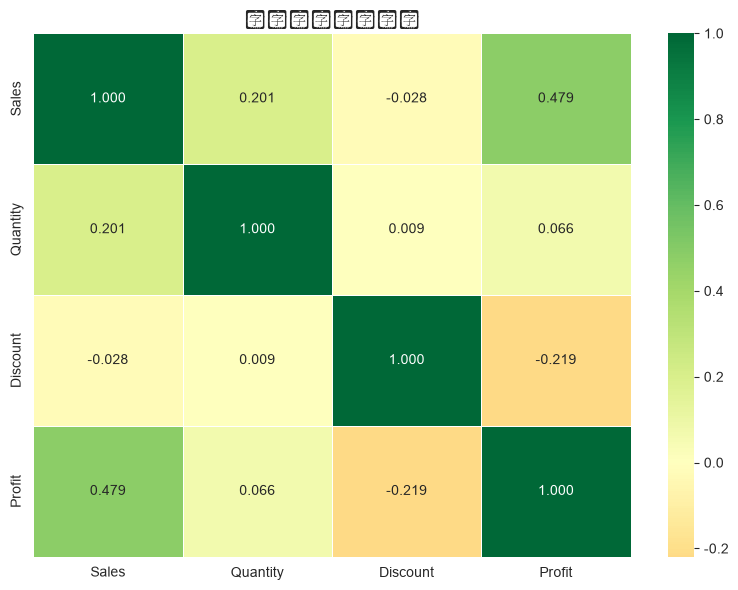

In [4]:
# 相关性分析
correlation = df[['Sales', 'Quantity', 'Discount', 'Profit']].corr()

print('='*50)
print('📊 相关性矩阵')
print('='*50)
print(correlation.round(3))

# 热力图
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(correlation, annot=True, fmt='.3f', cmap='RdYlGn', 
            center=0, ax=ax, linewidths=0.5)
ax.set_title('变量相关性热力图', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. 亏损订单分析

In [5]:
# 亏损订单统计
loss_orders = df[df['Profit'] < 0]
profit_orders = df[df['Profit'] >= 0]

print('='*60)
print('📊 订单盈亏统计')
print('='*60)
print(f'盈利订单数：{len(profit_orders)} ({len(profit_orders)/len(df)*100:.1f}%)')
print(f'亏损订单数：{len(loss_orders)} ({len(loss_orders)/len(df)*100:.1f}%)')
print(f'\n盈利订单总利润：${profit_orders["Profit"].sum():,.2f}')
print(f'亏损订单总亏损：${loss_orders["Profit"].sum():,.2f}')
print(f'\n平均盈利：${profit_orders["Profit"].mean():,.2f}')
print(f'平均亏损：${loss_orders["Profit"].mean():,.2f}')

📊 订单盈亏统计
盈利订单数：8123 (81.3%)
亏损订单数：1871 (18.7%)

盈利订单总利润：$442,528.31
亏损订单总亏损：$-156,131.29

平均盈利：$54.48
平均亏损：$-83.45


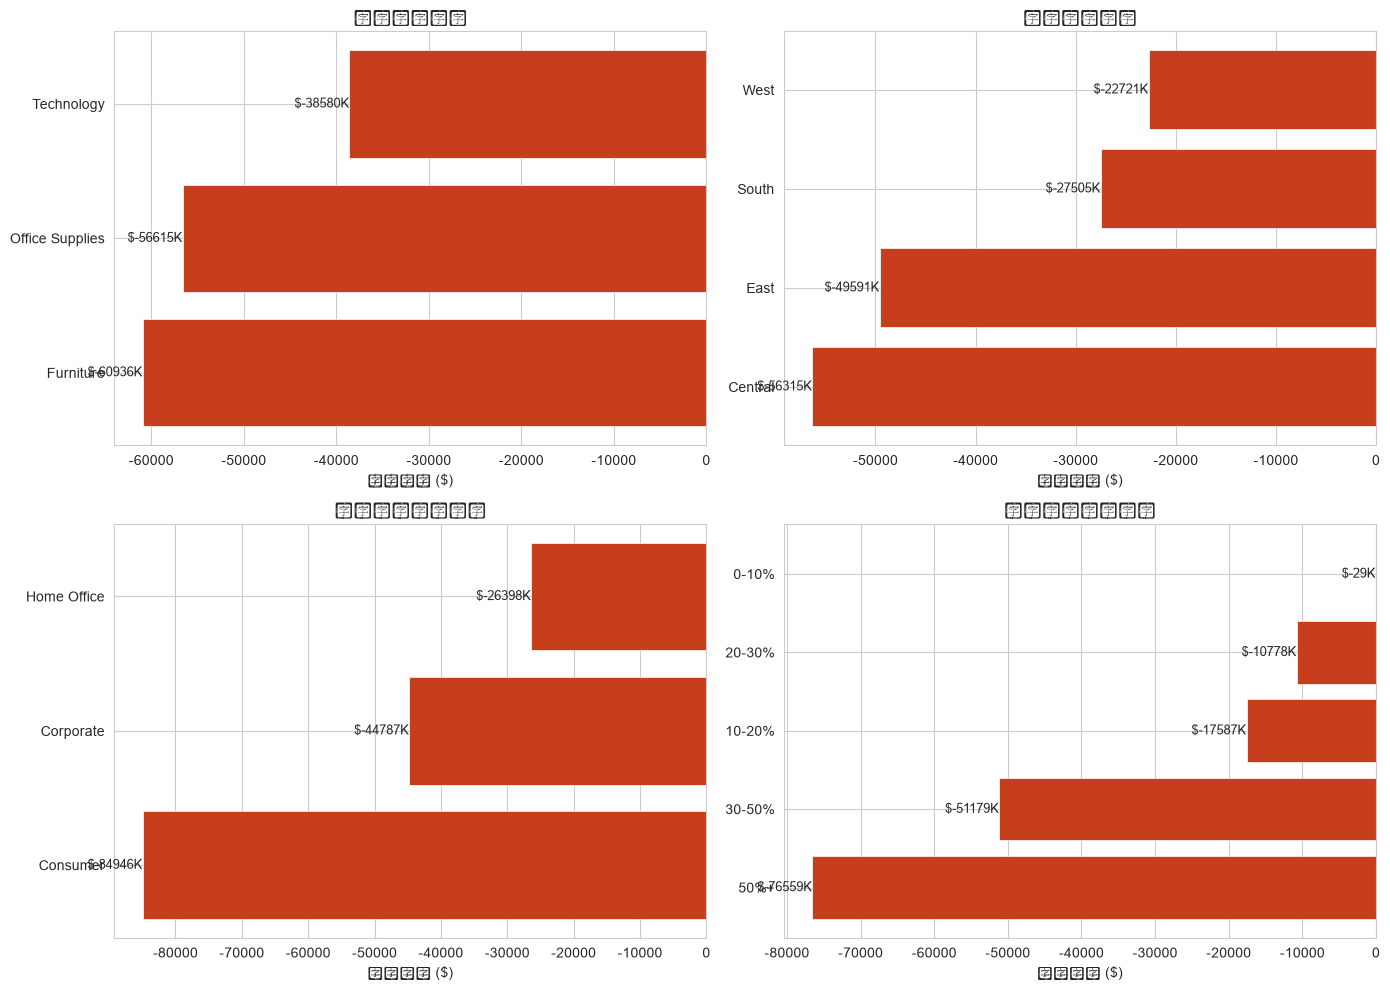

In [6]:
# 亏损订单按维度分析
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 按品类
loss_by_category = loss_orders.groupby('Category').agg({
    'Profit': 'sum',
    'Order ID': 'nunique'
}).reset_index()
loss_by_category = loss_by_category.sort_values('Profit')

bars = axes[0, 0].barh(loss_by_category['Category'], loss_by_category['Profit'],
                       color='#C73E1D', edgecolor='white', linewidth=0.5)
axes[0, 0].set_xlabel('亏损金额 ($)')
axes[0, 0].set_title('按品类的亏损', fontsize=12, fontweight='bold')
axes[0, 0].bar_label(bars, fmt='$%.0fK', fontsize=9)

# 按区域
loss_by_region = loss_orders.groupby('Region').agg({
    'Profit': 'sum',
    'Order ID': 'nunique'
}).reset_index()
loss_by_region = loss_by_region.sort_values('Profit')

bars = axes[0, 1].barh(loss_by_region['Region'], loss_by_region['Profit'],
                       color='#C73E1D', edgecolor='white', linewidth=0.5)
axes[0, 1].set_xlabel('亏损金额 ($)')
axes[0, 1].set_title('按区域的亏损', fontsize=12, fontweight='bold')
axes[0, 1].bar_label(bars, fmt='$%.0fK', fontsize=9)

# 按客户类型
loss_by_segment = loss_orders.groupby('Segment').agg({
    'Profit': 'sum',
    'Order ID': 'nunique'
}).reset_index()
loss_by_segment = loss_by_segment.sort_values('Profit')

bars = axes[1, 0].barh(loss_by_segment['Segment'], loss_by_segment['Profit'],
                       color='#C73E1D', edgecolor='white', linewidth=0.5)
axes[1, 0].set_xlabel('亏损金额 ($)')
axes[1, 0].set_title('按客户类型的亏损', fontsize=12, fontweight='bold')
axes[1, 0].bar_label(bars, fmt='$%.0fK', fontsize=9)

# 按折扣区间
loss_by_discount = loss_orders.groupby('Discount Range').agg({
    'Profit': 'sum',
    'Order ID': 'nunique'
}).reset_index()
loss_by_discount = loss_by_discount.sort_values('Profit')

bars = axes[1, 1].barh(loss_by_discount['Discount Range'].astype(str), loss_by_discount['Profit'],
                       color='#C73E1D', edgecolor='white', linewidth=0.5)
axes[1, 1].set_xlabel('亏损金额 ($)')
axes[1, 1].set_title('按折扣区间的亏损', fontsize=12, fontweight='bold')
axes[1, 1].bar_label(bars, fmt='$%.0fK', fontsize=9)

plt.tight_layout()
plt.show()

## 3. 高折扣产品分析

In [7]:
# 高折扣产品（折扣>30%）
high_discount = df[df['Discount'] > 0.3]

print('='*60)
print('📊 高折扣产品统计（折扣>30%）')
print('='*60)
print(f'订单数：{len(high_discount)} ({len(high_discount)/len(df)*100:.1f}%)')
print(f'总销售额：${high_discount["Sales"].sum():,.2f}')
print(f'总利润：${high_discount["Profit"].sum():,.2f}')
print(f'平均折扣：{high_discount["Discount"].mean()*100:.1f}%')
print(f'平均利润率：{(high_discount["Profit"].sum()/high_discount["Sales"].sum()*100):.1f}%')

# 按品类的高折扣分布
high_discount_by_cat = high_discount.groupby('Category').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order ID': 'nunique'
}).reset_index()
high_discount_by_cat['Profit Margin'] = (high_discount_by_cat['Profit'] / high_discount_by_cat['Sales'] * 100).round(2)

print()
print('='*60)
print('📊 高折扣产品按品类')
print('='*60)
print(high_discount_by_cat.to_string(index=False))

📊 高折扣产品统计（折扣>30%）
订单数：1166 (11.7%)
总销售额：$259,543.49
总利润：$-125,006.78
平均折扣：63.8%
平均利润率：-48.2%

📊 高折扣产品按品类
       Category       Sales      Profit  Order ID  Profit Margin
      Furniture  95680.3908 -43782.4392       296         -45.76
Office Supplies  39523.1470 -47140.1376       573        -119.27
     Technology 124339.9570 -34084.2018       147         -27.41


📊 高折扣产品子品类分析
       Category Sub-Category      Sales      Profit  Discount  Profit Margin
Office Supplies      Binders 36140.6130 -38510.4964  0.738010        -106.56
     Technology     Machines 73082.8030 -29881.3916  0.568750         -40.89
      Furniture       Tables 64774.3900 -27295.8952  0.434016         -42.14
      Furniture    Bookcases 24261.3008 -10541.8888  0.469000         -43.45
Office Supplies   Appliances  3382.5340  -8629.6412  0.800000        -255.12
     Technology       Phones 34337.3520  -6385.7854  0.400000         -18.60
      Furniture  Furnishings  6644.7000  -5944.6552  0.600000         -89.46
     Technology      Copiers 16919.8020   2182.9752  0.400000          12.90


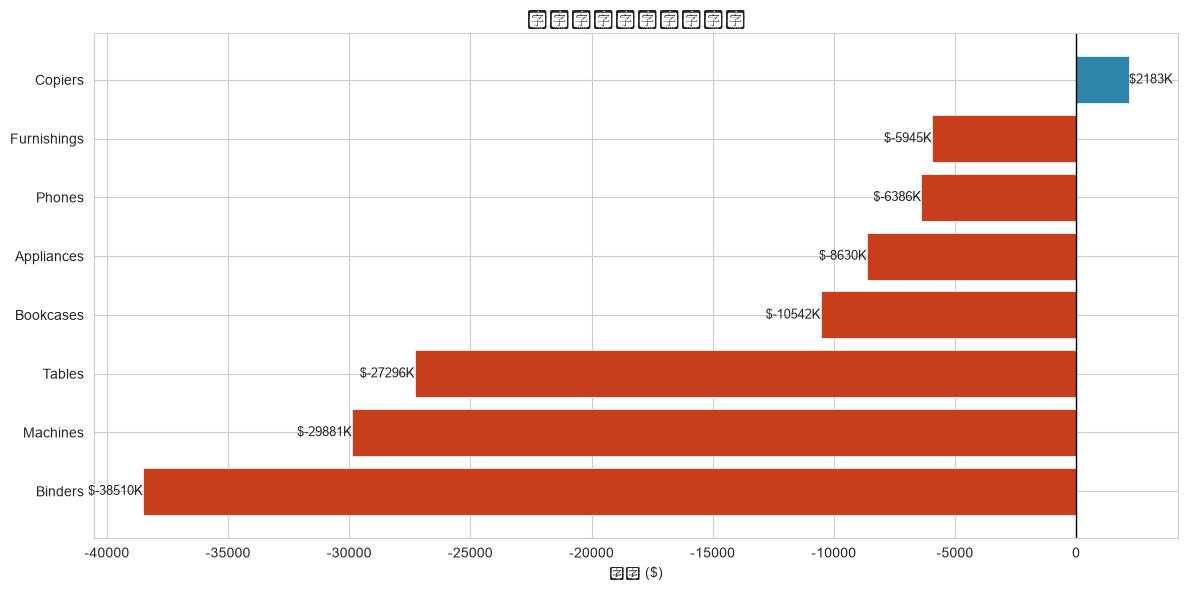

In [8]:
# 高折扣产品的子品类分析
high_discount_subcat = high_discount.groupby(['Category', 'Sub-Category']).agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Discount': 'mean'
}).reset_index()
high_discount_subcat['Profit Margin'] = (high_discount_subcat['Profit'] / high_discount_subcat['Sales'] * 100).round(2)
high_discount_subcat = high_discount_subcat.sort_values('Profit')

print('='*70)
print('📊 高折扣产品子品类分析')
print('='*70)
print(high_discount_subcat.to_string(index=False))

# 可视化
fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#C73E1D' if x < 0 else '#2E86AB' for x in high_discount_subcat['Profit']]
bars = ax.barh(high_discount_subcat['Sub-Category'], high_discount_subcat['Profit'],
               color=colors, edgecolor='white', linewidth=0.5)
ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax.set_xlabel('利润 ($)')
ax.set_title('高折扣子品类利润分布', fontsize=14, fontweight='bold')
ax.bar_label(bars, fmt='$%.0fK', fontsize=9)
plt.tight_layout()
plt.show()

## 4. 盈利能力分析

📊 盈利能力分层
Profit Tier  Total Sales  Order Count  Total Profit  Sales Share
     亏损>100  259539.5463          311  -121504.6754        11.30
   亏损10-100  180244.9841          905   -31620.9352         7.85
     亏损0-10   56609.4714          720    -3005.6751         2.46
     盈利0-10  104568.3130         3451    16352.3544         4.55
   盈利10-100  645241.8595         3717   126000.9001        28.09
     盈利>100 1050996.6860          890   300175.0529        45.75


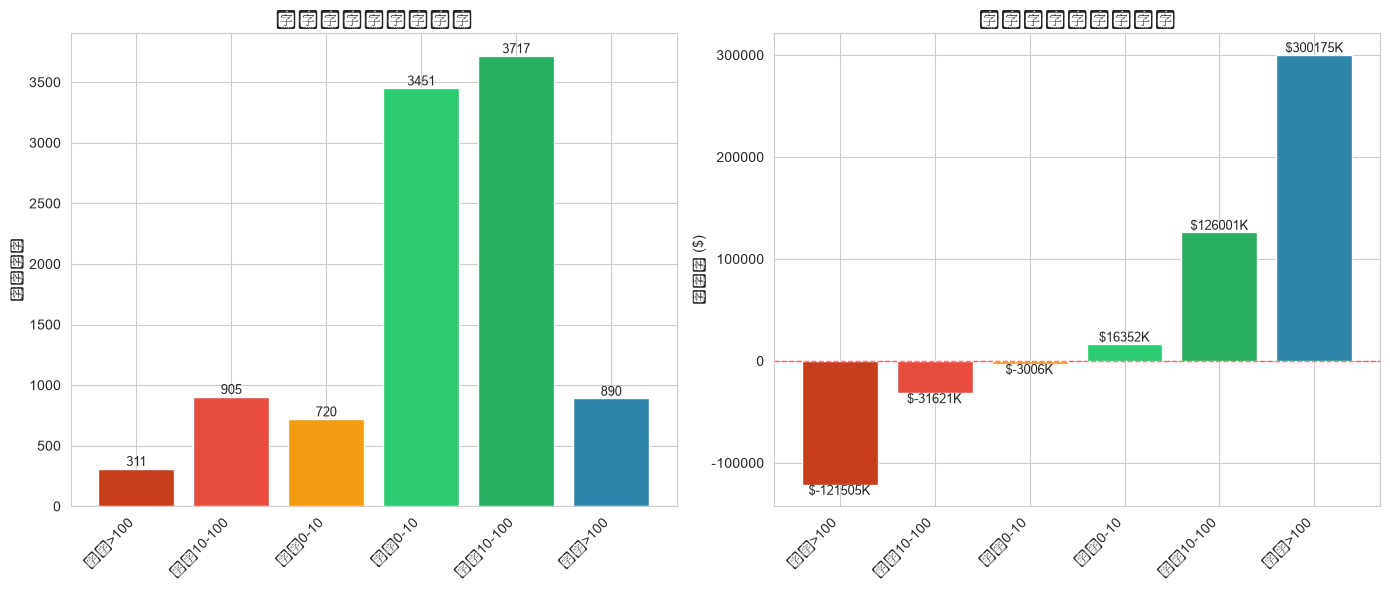

In [9]:
# 盈利能力分层
profit_tiers = pd.cut(df['Profit'], 
                      bins=[float('-inf'), -100, -10, 0, 10, 100, float('inf')],
                      labels=['亏损>100', '亏损10-100', '亏损0-10', '盈利0-10', '盈利10-100', '盈利>100'])

tier_analysis = df.groupby(profit_tiers).agg({
    'Sales': ['sum', 'count'],
    'Profit': 'sum'
}).reset_index()
tier_analysis.columns = ['Profit Tier', 'Total Sales', 'Order Count', 'Total Profit']
tier_analysis['Sales Share'] = (tier_analysis['Total Sales'] / tier_analysis['Total Sales'].sum() * 100).round(2)

print('='*70)
print('📊 盈利能力分层')
print('='*70)
print(tier_analysis.to_string(index=False))

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 订单数量分布
colors = ['#C73E1D', '#E74C3C', '#F39C12', '#2ECC71', '#27AE60', '#2E86AB']
bars = axes[0].bar(range(len(tier_analysis)), tier_analysis['Order Count'],
                   color=colors, edgecolor='white', linewidth=1)
axes[0].set_xticks(range(len(tier_analysis)))
axes[0].set_xticklabels(tier_analysis['Profit Tier'], rotation=45, ha='right')
axes[0].set_ylabel('订单数量')
axes[0].set_title('各盈利层级订单数量', fontsize=14, fontweight='bold')
axes[0].bar_label(bars, fontsize=9)

# 利润贡献
bars = axes[1].bar(range(len(tier_analysis)), tier_analysis['Total Profit'],
                   color=colors, edgecolor='white', linewidth=1)
axes[1].set_xticks(range(len(tier_analysis)))
axes[1].set_xticklabels(tier_analysis['Profit Tier'], rotation=45, ha='right')
axes[1].set_ylabel('总利润 ($)')
axes[1].set_title('各盈利层级利润贡献', fontsize=14, fontweight='bold')
axes[1].bar_label(bars, fmt='$%.0fK', fontsize=9)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.show()

## 5. 业务建议

In [10]:
# 计算关键指标
total_loss = loss_orders['Profit'].sum()
high_discount_loss = high_discount[high_discount['Profit'] < 0]['Profit'].sum()
furniture_loss = df[df['Category'] == 'Furniture']['Profit'].sum()

print('='*60)
print('💡 业务建议')
print('='*60)

print('\n1️⃣ 折扣策略优化')
print(f'   - 高折扣（>30%）导致亏损：${abs(high_discount_loss):,.0f}')
print(f'   - 建议：控制折扣在20%以内，避免过度折扣')

print('\n2️⃣ 品类结构调整')
print(f'   - Furniture 利润率仅 2.5%，其中 Tables 和 Bookcases 亏损')
print(f'   - 建议：减少低利润产品的库存，或提高售价')

print('\n3️⃣ 区域策略')
print(f'   - Central 区域利润率最低（7.9%）')
print(f'   - 建议：优化Central区域的定价和促销策略')

print('\n4️⃣ 客户管理')
print(f'   - Consumer 占比50.6%但利润率最低（11.6%）')
print(f'   - 建议：提升Consumer客户的客单价和复购率')

print('\n5️⃣ 产品优化')
print(f'   - Copiers 利润率最高（37.2%），但订单量少')
print(f'   - 建议：加大高利润产品的推广力度')

print('\n' + '='*60)
print('📊 预期效果')
print('='*60)
print(f'   - 如果消除高折扣亏损，可增加利润：${abs(high_discount_loss):,.0f}')
print(f'   - 如果Furniture利润率提升至10%，可增加利润：${(df[df["Category"]=="Furniture"]["Sales"].sum()*0.1 - furniture_loss):,.0f}')

💡 业务建议

1️⃣ 折扣策略优化
   - 高折扣（>30%）导致亏损：$127,738
   - 建议：控制折扣在20%以内，避免过度折扣

2️⃣ 品类结构调整
   - Furniture 利润率仅 2.5%，其中 Tables 和 Bookcases 亏损
   - 建议：减少低利润产品的库存，或提高售价

3️⃣ 区域策略
   - Central 区域利润率最低（7.9%）
   - 建议：优化Central区域的定价和促销策略

4️⃣ 客户管理
   - Consumer 占比50.6%但利润率最低（11.6%）
   - 建议：提升Consumer客户的客单价和复购率

5️⃣ 产品优化
   - Copiers 利润率最高（37.2%），但订单量少
   - 建议：加大高利润产品的推广力度

📊 预期效果
   - 如果消除高折扣亏损，可增加利润：$127,738


   - 如果Furniture利润率提升至10%，可增加利润：$55,749


## 6. 总结

In [11]:
print('='*60)
print('📊 分析总结')
print('='*60)

print('\n🎯 核心发现：')
print('   1. 折扣与利润强负相关（-0.22）')
print('   2. 折扣>30%时几乎必然亏损')
print('   3. Furniture品类利润率极低（2.5%）')
print('   4. Central区域表现最差')
print('   5. 高价值客户（Sean Miller）实际亏损')

print('\n🏆 最佳实践：')
print('   - Technology品类：高利润率（17.4%）')
print('   - Copiers子品类：利润率最高（37.2%）')
print('   - West区域：表现最好（利润率14.9%）')
print('   - Home Office客户：利润率最高（14.0%）')

print('\n⚠️  风险点：')
print('   - 过度折扣导致亏损')
print('   - 低利润品类拖累整体表现')
print('   - 部分区域/客户类型盈利能力弱')

📊 分析总结

🎯 核心发现：
   1. 折扣与利润强负相关（-0.22）
   2. 折扣>30%时几乎必然亏损
   3. Furniture品类利润率极低（2.5%）
   4. Central区域表现最差
   5. 高价值客户（Sean Miller）实际亏损

🏆 最佳实践：
   - Technology品类：高利润率（17.4%）
   - Copiers子品类：利润率最高（37.2%）
   - West区域：表现最好（利润率14.9%）
   - Home Office客户：利润率最高（14.0%）

⚠️  风险点：
   - 过度折扣导致亏损
   - 低利润品类拖累整体表现
   - 部分区域/客户类型盈利能力弱
